In [1]:
import numpy as np
import matplotlib.pyplot as plt
import casadi.casadi as cs

np.random.seed(42)

In [2]:
# Track geometry (problem statement: R=50, r=46, rho=20, d=100)
d   = 100.0
rho = 20.0
L   = 2*d + 2*np.pi*rho

print(f"Track perimeter: {L:.2f} m")
print(f"One lap at 10 m/s: {L/10:.1f} s")

Track perimeter: 325.66 m
One lap at 10 m/s: 32.6 s


In [3]:
def s_to_xy(s):
    """Arc-length s -> Cartesian (x, y) on centreline."""
    s = s % L
    if s < d:
        return np.array([s, rho])
    elif s < d + np.pi*rho:
        theta = (s - d) / rho
        return np.array([d + rho*np.sin(theta), rho*np.cos(theta)])
    elif s < 2*d + np.pi*rho:
        return np.array([2*d + np.pi*rho - s, -rho])
    else:
        theta = (s - (2*d + np.pi*rho)) / rho
        return np.array([-rho*np.sin(theta), -rho*np.cos(theta)])

def s_to_normal(s):
    """Unit inward normal to centreline at arc-length s."""
    s = s % L
    if s < d:
        return np.array([0.0, -1.0])
    elif s < d + np.pi*rho:
        theta = (s - d) / rho
        return np.array([-np.sin(theta), -np.cos(theta)])
    elif s < 2*d + np.pi*rho:
        return np.array([0.0, 1.0])
    else:
        theta = (s - (2*d + np.pi*rho)) / rho
        return np.array([np.sin(theta), np.cos(theta)])

def sl_to_xy(s, ell):
    """(arc-length s, lateral offset ell) -> Cartesian (x, y)."""
    return s_to_xy(s) + ell * s_to_normal(s)

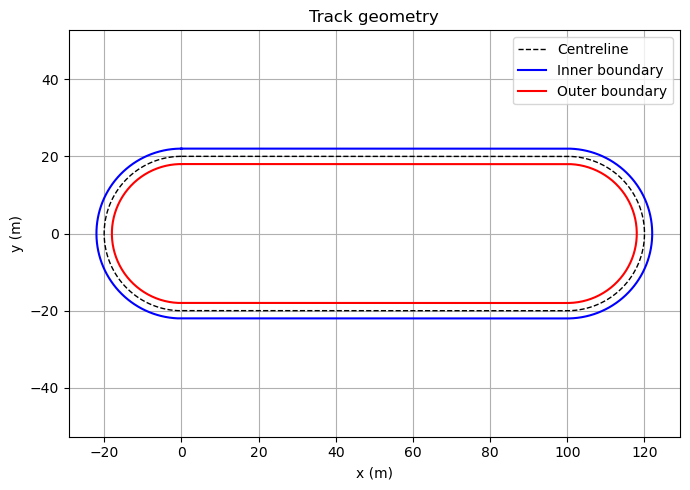

In [4]:
s_vals = np.linspace(0, L, 1000)
centre = np.array([s_to_xy(s)    for s in s_vals])
inner  = np.array([sl_to_xy(s, -2.0) for s in s_vals])
outer  = np.array([sl_to_xy(s,  2.0) for s in s_vals])

plt.figure(figsize=(7, 5))
plt.plot(centre[:,0], centre[:,1], 'k--', lw=1,   label='Centreline')
plt.plot(inner[:,0],  inner[:,1],  'b-',  lw=1.5, label='Inner boundary')
plt.plot(outer[:,0],  outer[:,1],  'r-',  lw=1.5, label='Outer boundary')
plt.axis('equal')
plt.grid(True)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Track geometry')
plt.legend()
plt.tight_layout()
plt.show()